In [1]:
import pandas as pd
import numpy as np
import os

processed_path = os.path.join("..", "Data", "Processed")

transactions = pd.read_csv(os.path.join(processed_path, "transactions_clean.csv"))
transactions['InvoiceDate'] = pd.to_datetime(transactions['InvoiceDate'])

customer_segments = pd.read_csv(os.path.join(processed_path, "customer_segments.csv"))

transactions.shape, customer_segments.shape

((805549, 11), (5878, 8))

In [2]:
order_level = transactions.groupby(['Customer ID', 'Invoice'])['InvoiceDate'].first().reset_index()
order_level = order_level.sort_values(['Customer ID', 'InvoiceDate'])

order_level['days_since_prev_order'] = order_level.groupby('Customer ID')['InvoiceDate'].diff().dt.days

order_level['days_since_prev_order'].describe()

count    31091.000000
mean        51.239426
std         75.754392
min          0.000000
25%          6.000000
50%         24.000000
75%         61.000000
max        714.000000
Name: days_since_prev_order, dtype: float64

In [3]:
reference_date = transactions['InvoiceDate'].max() + pd.Timedelta(days=1)

last_purchase = transactions.groupby('Customer ID')['InvoiceDate'].max()
days_since_last_purchase = (reference_date - last_purchase).dt.days

churn_labels = (days_since_last_purchase > 75).astype(int).rename('Churned')
churn_labels.value_counts()

Churned
1    3181
0    2697
Name: count, dtype: int64

In [4]:
churn_labels = churn_labels.reset_index()

model_data = customer_segments.merge(churn_labels, on='Customer ID', how='left')
model_data[['Customer ID', 'Recency', 'Frequency', 'Monetary', 'Cancel_Count', 'predicted_clv', 'Segment', 'Churned']].head()

,Customer ID,Recency,Frequency,Monetary,Cancel_Count,predicted_clv,Segment,Churned
0,12346,326,12,77556.46,14,25962.373049,Champions,1
1,12347,2,8,5633.32,0,3981.252162,Champions,0
2,12348,75,5,2019.40,0,1413.954074,At-Risk,0
3,12349,19,4,4428.69,5,2179.239819,New/Occasional,0
4,12350,310,1,334.40,0,NaN,Lost/Inactive,1


In [5]:
from sklearn.model_selection import train_test_split

# One-hot encode Segment since it's categorical
model_data_encoded = pd.get_dummies(model_data, columns=['Segment'], drop_first=True)

feature_cols = ['Frequency', 'Monetary', 'Cancel_Count', 'predicted_clv'] + \
                [col for col in model_data_encoded.columns if col.startswith('Segment_')]

X = model_data_encoded[feature_cols]
y = model_data_encoded['Churned']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

X_train.shape, X_test.shape

((4702, 7), (1176, 7))

In [6]:
X.isnull().sum()

Frequency                    0
Monetary                     0
Cancel_Count                 0
predicted_clv             1287
Segment_Champions            0
Segment_Lost/Inactive        0
Segment_New/Occasional       0
dtype: int64

In [7]:
missing_clv = model_data[model_data['predicted_clv'].isnull()]
missing_clv['Segment'].value_counts()

Segment
Lost/Inactive     1017
New/Occasional     243
At-Risk             26
Champions            1
Name: count, dtype: int64

In [8]:
model_data_encoded = pd.get_dummies(model_data, columns=['Segment'], drop_first=True)
model_data_encoded['predicted_clv'] = model_data_encoded['predicted_clv'].fillna(0)

feature_cols = ['Frequency', 'Monetary', 'Cancel_Count', 'predicted_clv'] + \
                [col for col in model_data_encoded.columns if col.startswith('Segment_')]

X = model_data_encoded[feature_cols]
y = model_data_encoded['Churned']

X.isnull().sum()

Frequency                 0
Monetary                  0
Cancel_Count              0
predicted_clv             0
Segment_Champions         0
Segment_Lost/Inactive     0
Segment_New/Occasional    0
dtype: int64

In [9]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

X_train.shape, X_test.shape

((4702, 7), (1176, 7))

In [10]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, roc_auc_score

logreg = LogisticRegression(random_state=42, max_iter=1000)
logreg.fit(X_train, y_train)

y_pred = logreg.predict(X_test)
y_pred_proba = logreg.predict_proba(X_test)[:, 1]

print(classification_report(y_test, y_pred))
print("ROC AUC:", roc_auc_score(y_test, y_pred_proba))

              precision    recall  f1-score   support

           0       0.94      0.89      0.91       540
           1       0.91      0.95      0.93       636

    accuracy                           0.92      1176
   macro avg       0.92      0.92      0.92      1176
weighted avg       0.92      0.92      0.92      1176

ROC AUC: 0.9536920568367109


In [11]:
importance = pd.Series(logreg.coef_[0], index=X.columns).sort_values()
importance

Segment_New/Occasional   -4.943254
Segment_Champions        -3.601262
Frequency                -0.077295
Cancel_Count             -0.005828
predicted_clv            -0.002041
Monetary                  0.000875
Segment_Lost/Inactive     0.879257
dtype: float64

In [12]:
model_data.groupby('Segment')['Churned'].mean().round(3).sort_values(ascending=False)

Segment
Lost/Inactive     0.950
At-Risk           0.819
Champions         0.056
New/Occasional    0.031
Name: Churned, dtype: float64

In [13]:
model_data.to_csv(os.path.join(processed_path, "customer_segments.csv"), index=False)

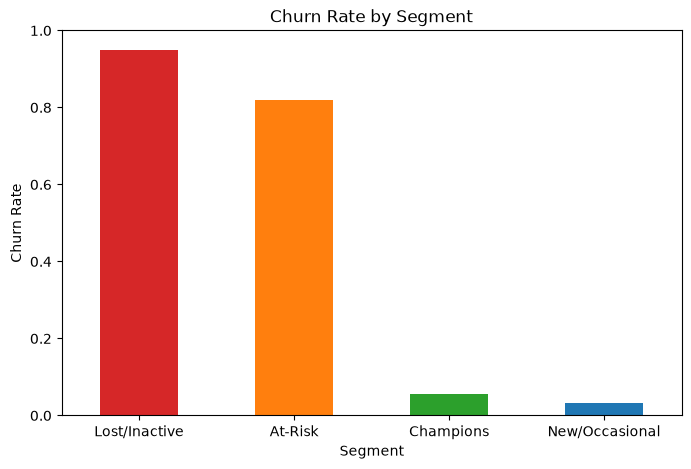

In [14]:
import matplotlib.pyplot as plt

churn_by_segment = model_data.groupby('Segment')['Churned'].mean().sort_values(ascending=False)

plt.figure(figsize=(8,5))
churn_by_segment.plot(kind='bar', color=['#d62728', '#ff7f0e', '#2ca02c', '#1f77b4'])
plt.ylabel('Churn Rate')
plt.title('Churn Rate by Segment')
plt.xticks(rotation=0)
plt.ylim(0, 1)
plt.show()